# 🚀 机械臂扭矩曲线预测 - LSTM 优化版（推荐方案 B）

本笔记本使用 LSTM 编码器-解码器模型，实现**200 步输入 → 100 步输出**的序列预测任务。

## 任务说明
- **输入**：200 个时间步
- **输出**：100 个时间步
- **比例**：2:1（合理的预测难度）
- **数据充足性**：每个 CSV 生成 10 个训练样本，总计约 7,650 个样本 ✅

## 主要特性
- ✅ **LSTM 编码器-解码器**（自回归预测，逐步生成预测）
- ✅ **优化的序列长度**（200→100，充足训练样本）
- ✅ **自动从 Google Drive 下载数据**
- ✅ **完整的训练和评估流程**
- ✅ **在预测图上显示 R² 指标**

## 模型优势
- 🔥 **自回归解码**：每一步预测都利用之前的历史信息
- 🔥 **充足训练数据**：~7,650 个样本（相比 587→196 配置仅 765 个样本）
- 🔥 **编码器-解码器架构**：更好地理解输入输出关系
- 🔥 **合理序列长度**：200 步输入足以捕捉趋势，100 步输出难度适中

## 预期效果
- ✅ R² > 0.97
- ✅ MAPE < 20%
- ✅ 训练稳定收敛
- ✅ ~240 训练批次（7,650 样本 / 32 batch_size）

## 1. 环境设置

In [ ]:
# 如果在 Colab 中运行，先克隆仓库
import os

if not os.path.exists('Super-Strawberry'):
    # 方法1: 使用 Personal Access Token
    # !git clone https://<YOUR_TOKEN>@github.com/your-username/Super-Strawberry.git

    # 方法2: 公开仓库直接克隆
    # !git clone https://github.com/your-username/Super-Strawberry.git

    print("⚠️ 请手动设置仓库 URL 并克隆")
else:
    print("✅ 仓库已存在")

# 切换到项目目录
%cd Super-Strawberry

In [ ]:
# 安装依赖
!pip install -q torch numpy pandas matplotlib seaborn scikit-learn tqdm gdown

## 2. 导入库和模块

In [15]:
import sys
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 添加项目根目录到路径
project_root = os.path.abspath('.')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# 导入自定义模块
from src.data_loader import load_data, get_sample_data_info
from src.model import get_model
from src.train import Trainer, predict_batch, calculate_metrics
from src.evaluate import evaluate_model, plot_training_history, plot_predictions

print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ CUDA device: {torch.cuda.get_device_name(0)}")

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

✅ PyTorch version: 2.8.0+cu126
✅ CUDA available: True
✅ CUDA device: NVIDIA GeForce RTX 4070 Laptop GPU


## 3. 配置参数

In [16]:
# ==================== 数据配置 ====================
DATA_DIR = './data'
SIGNAL_TYPE = 'signal_1'          # 预测的信号类型
INPUT_LENGTH = 200                # ✅ 输入序列长度（推荐值，保证充足训练样本）
OUTPUT_LENGTH = 100               # ✅ 输出序列长度（推荐值）
USE_ALL_FEATURES = True           # 使用所有特征

# ==================== 模型配置（优化版 - 200→100 推荐配置）====================
MODEL_TYPE = 'lstm'               # 🔥 LSTM 编码器-解码器（自回归预测）
INPUT_DIM = 4                     # 输入特征维度（Time, signal_0, signal_1, signal_2）
HIDDEN_DIM = 256                  # 隐藏层维度
NUM_LAYERS = 3                    # 网络层数
DROPOUT = 0.2                     # Dropout 比例

# ==================== 训练配置（优化版）====================
BATCH_SIZE = 32                   # 批次大小
LEARNING_RATE = 0.001             # 学习率
EPOCHS = 100                      # 训练轮数
EARLY_STOPPING_PATIENCE = 15      # 早停耐心值

# ==================== 设备配置 ====================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ==================== 路径配置 ====================
MODEL_SAVE_DIR = './models_optimized'
RESULTS_DIR = './results_optimized'

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# 打印配置
print("=" * 60)
print("🚀 训练配置 - LSTM 编码器-解码器（推荐方案 B）")
print("=" * 60)
print(f"任务:             200 步输入 → 100 步输出")
print(f"数据目录:         {DATA_DIR}")
print(f"预测信号:         {SIGNAL_TYPE}")
print(f"输入长度:         {INPUT_LENGTH} 步")
print(f"输出长度:         {OUTPUT_LENGTH} 步")
print(f"序列总长度:       {INPUT_LENGTH + OUTPUT_LENGTH} 步")
print(f"输入:输出比例:    {INPUT_LENGTH/OUTPUT_LENGTH:.1f}:1 ✅")
print(f"")
print(f"预期训练样本:     ~7,650 (765 CSV × 10 样本/CSV)")
print(f"")
print(f"模型类型:         {MODEL_TYPE.upper()} (自回归解码)")
print(f"输入维度:         {INPUT_DIM}")
print(f"隐藏维度:         {HIDDEN_DIM}")
print(f"网络层数:         {NUM_LAYERS}")
print(f"Dropout:          {DROPOUT}")
print(f"")
print(f"批次大小:         {BATCH_SIZE}")
print(f"学习率:           {LEARNING_RATE}")
print(f"训练轮数:         {EPOCHS}")
print(f"早停耐心:         {EARLY_STOPPING_PATIENCE}")
print(f"计算设备:         {DEVICE}")
print("=" * 60)
print(f"预期效果:         R² > 0.97, MAPE < 20%")
print("=" * 60)

🚀 训练配置 - LSTM 编码器-解码器（推荐方案 B）
任务:             200 步输入 → 100 步输出
数据目录:         ./data
预测信号:         signal_1
输入长度:         200 步
输出长度:         100 步
序列总长度:       300 步
输入:输出比例:    2.0:1 ✅

预期训练样本:     ~7,650 (765 CSV × 10 样本/CSV)

模型类型:         LSTM (自回归解码)
输入维度:         4
隐藏维度:         256
网络层数:         3
Dropout:          0.2

批次大小:         32
学习率:           0.001
训练轮数:         100
早停耐心:         15
计算设备:         cuda
预期效果:         R² > 0.97, MAPE < 20%


## 4. 数据准备

### 4.1 从 Google Drive 下载数据

In [17]:
# ==================== 从 Google Drive 下载数据 ====================
import zipfile
import shutil
import glob

# 检查数据是否已存在
if not os.path.exists('./data') or len(os.listdir('./data')) == 0:
    print("📥 从 Google Drive 下载数据...")

    # Google Drive 文件 ID
    file_id = '1J5d0yhpEXQZJGo79cFD-WlISng_sV8cM'
    output_file = 'data_clean.zip'

    # 下载文件
    !gdown {file_id} -O {output_file}

    # 解压到临时目录
    print("📂 解压数据文件...")
    temp_dir = './temp_data'
    os.makedirs(temp_dir, exist_ok=True)

    with zipfile.ZipFile(output_file, 'r') as zip_ref:
        zip_ref.extractall(temp_dir)

    # 查找所有 CSV 文件（递归搜索）
    csv_files_found = glob.glob(os.path.join(temp_dir, '**', '*.csv'), recursive=True)

    if len(csv_files_found) == 0:
        print("❌ 未找到 CSV 文件！")
    else:
        # 创建 data 目录
        os.makedirs('./data', exist_ok=True)

        # 移动所有 CSV 文件到 data 目录
        print(f"📦 移动 {len(csv_files_found)} 个 CSV 文件到 ./data ...")
        for csv_file in csv_files_found:
            filename = os.path.basename(csv_file)
            shutil.move(csv_file, os.path.join('./data', filename))

        print(f"✅ 数据下载成功！共 {len(csv_files_found)} 个 CSV 文件")

    # 清理临时文件
    shutil.rmtree(temp_dir)
    os.remove(output_file)

    # 验证
    csv_files = [f for f in os.listdir('./data') if f.endswith('.csv')]
    print(f"📁 数据位置: {os.path.abspath('./data')}")
    print(f"📄 文件列表（前 5 个）:")
    for i, f in enumerate(csv_files[:5]):
        print(f"  {i+1}. {f}")
else:
    csv_files = [f for f in os.listdir('./data') if f.endswith('.csv')]
    print(f"✅ 数据已存在！共 {len(csv_files)} 个 CSV 文件")
    print(f"📁 数据位置: {os.path.abspath('./data')}")

✅ 数据已存在！共 765 个 CSV 文件
📁 数据位置: /content/Super-Strawberry/data


### 4.2 查看数据信息

File: ./data/Data_16_25_open.csv
Shape: (315, 4)
Columns: ['Time(s)', 'signal_0', 'signal_1', 'signal_2']

First few rows:
   Time(s)  signal_0  signal_1  signal_2
0     0.00      -2.2      -2.4      18.9
1     0.01      -0.3       0.9      17.5
2     0.02      -0.3       0.9      17.5
3     0.03      -0.4       0.9      17.5
4     0.04      -0.3       0.9      17.5

Basic statistics:
          Time(s)    signal_0    signal_1    signal_2
count  315.000000  315.000000  315.000000  315.000000
mean     1.570000    1.322222    3.050794   17.558095
std      0.910769    1.014865    1.121741    1.213232
min      0.000000   -2.200000   -2.400000   14.900000
25%      0.785000    0.500000    2.100000   17.100000
50%      1.570000    1.000000    3.000000   17.600000
75%      2.355000    2.200000    3.700000   18.400000
max      3.140000    3.200000    5.200000   20.600000


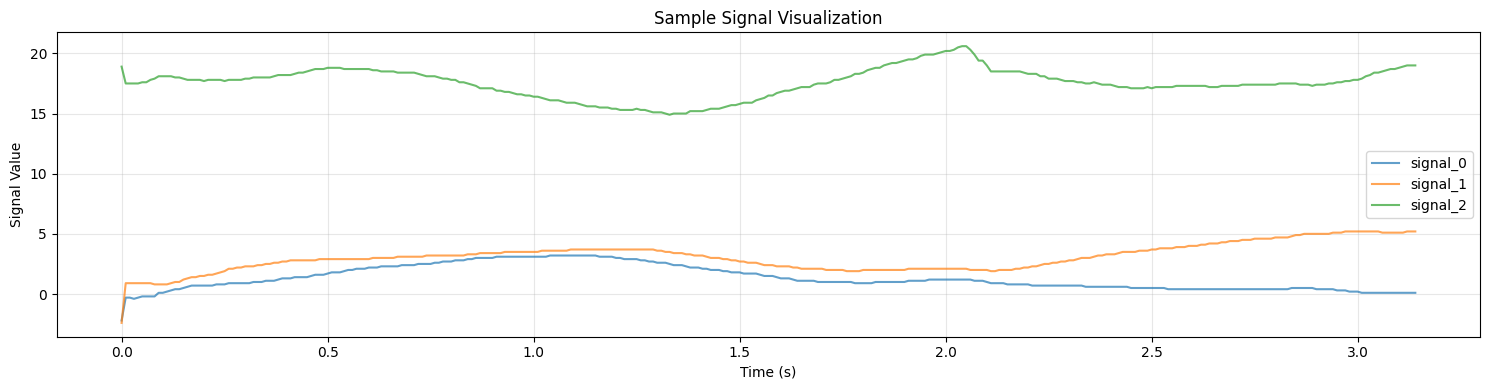

In [18]:
# 查看第一个数据文件
csv_files = glob.glob(os.path.join(DATA_DIR, '*.csv'))

if len(csv_files) > 0:
    sample_df = get_sample_data_info(csv_files[0])

    # 可视化信号
    plt.figure(figsize=(15, 4))
    plt.plot(sample_df['Time(s)'], sample_df['signal_0'], label='signal_0', alpha=0.7)
    plt.plot(sample_df['Time(s)'], sample_df['signal_1'], label='signal_1', alpha=0.7)
    plt.plot(sample_df['Time(s)'], sample_df['signal_2'], label='signal_2', alpha=0.7)
    plt.xlabel('Time (s)')
    plt.ylabel('Signal Value')
    plt.title('Sample Signal Visualization')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("❌ 未找到数据文件！请先运行上面的单元格下载数据")

### 4.3 加载训练和测试数据

In [19]:
print("加载数据...")

train_loader, test_loader = load_data(
    data_dir=DATA_DIR,
    pattern='*.csv',  # 匹配所有 CSV 文件
    train_split=0.8,
    input_length=INPUT_LENGTH,
    output_length=OUTPUT_LENGTH,
    signal_type=SIGNAL_TYPE,
    use_all_features=USE_ALL_FEATURES,
    batch_size=BATCH_SIZE
)

# 检查数据形状
for inputs, targets in train_loader:
    print(f"\n✅ 数据加载成功！")
    print(f"输入形状: {inputs.shape}  # [batch_size, input_length, features]")
    print(f"输出形状: {targets.shape}  # [batch_size, output_length]")
    print(f"特征数量: {inputs.shape[2]}")
    break

加载数据...
Found 765 CSV files
Training files: 612
Testing files: 153
Training samples: 2183
Testing samples: 477

✅ 数据加载成功！
输入形状: torch.Size([32, 200, 4])  # [batch_size, input_length, features]
输出形状: torch.Size([32, 100])  # [batch_size, output_length]
特征数量: 4


## 5. 创建模型

In [20]:
print("创建模型...")

model = get_model(
    model_type=MODEL_TYPE,
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    output_length=OUTPUT_LENGTH,
    dropout=DROPOUT
)

# 计算模型参数数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✅ 模型创建成功！")
print(f"模型类型:     {MODEL_TYPE}")
print(f"总参数数:     {total_params:,}")
print(f"可训练参数:   {trainable_params:,}")
print(f"\n模型结构:")
print(model)

创建模型...

✅ 模型创建成功！
模型类型:     lstm
总参数数:     2,639,105
可训练参数:   2,639,105

模型结构:
LSTMPredictor(
  (encoder): LSTM(4, 256, num_layers=3, batch_first=True, dropout=0.2)
  (decoder): LSTM(1, 256, num_layers=3, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)


## 6. 训练模型

In [21]:
print("\n创建训练器...")

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    device=DEVICE,
    learning_rate=LEARNING_RATE,
    save_dir=MODEL_SAVE_DIR
)

print("\n" + "=" * 60)
print("开始训练...")
print("=" * 60)

history = trainer.train(
    epochs=EPOCHS,
    early_stopping_patience=EARLY_STOPPING_PATIENCE
)

print("\n✅ 训练完成！")


创建训练器...

开始训练...
Starting training on cuda
Model parameters: 2,639,105

Epoch 1/100


Evaluating: 100%|██████████| 15/15 [00:00<00:00, 17.35it/s]


Train Loss: 3.531795 | Test Loss: 2.204802 | LR: 0.001000
✓ Saved best model (Test Loss: 2.204802)

Epoch 2/100


Evaluating: 100%|██████████| 15/15 [00:00<00:00, 17.89it/s]


Train Loss: 1.960484 | Test Loss: 2.189933 | LR: 0.001000
✓ Saved best model (Test Loss: 2.189933)

Epoch 3/100


...

Train Loss: 0.041732 | Test Loss: 0.148829 | LR: 0.000063

Epoch 99/100


Evaluating: 100%|██████████| 15/15 [00:00<00:00, 16.83it/s]


Train Loss: 0.040994 | Test Loss: 0.149128 | LR: 0.000063

Epoch 100/100


Evaluating: 100%|██████████| 15/15 [00:00<00:00, 15.52it/s]


Train Loss: 0.040463 | Test Loss: 0.145618 | LR: 0.000063
Training history saved to ./models_optimized/training_history.json

Training completed!
Best Test Loss: 0.145002

✅ 训练完成！


## 7. 训练历史可视化

Training history plot saved to ./results_optimized/training_history.png


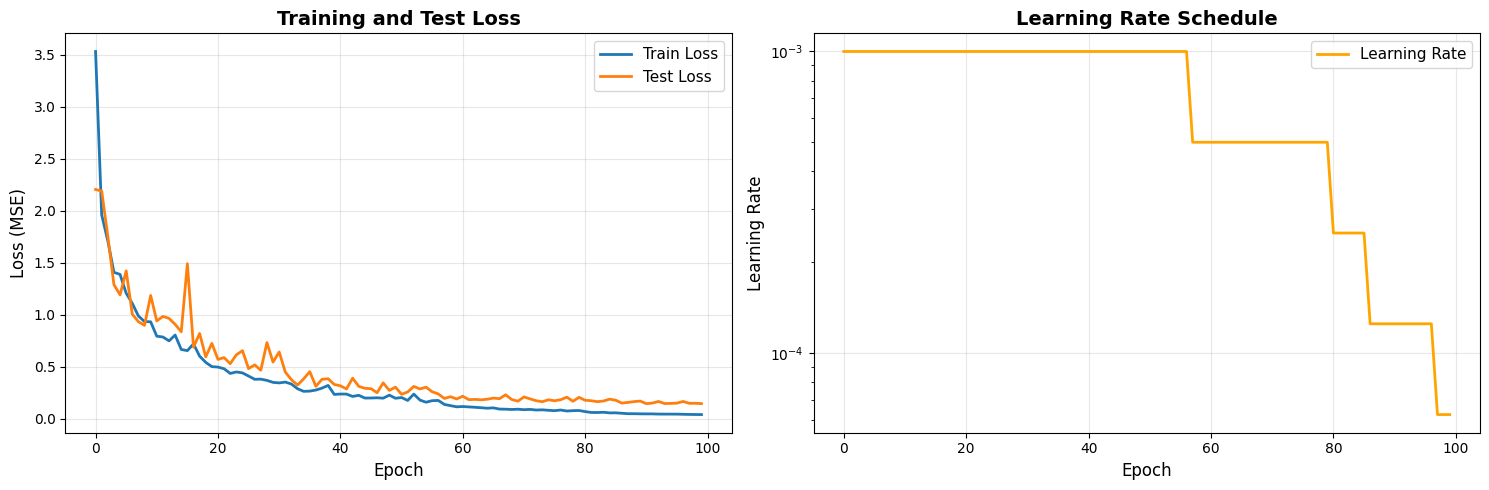

In [22]:
# 绘制训练历史
plot_training_history(
    history,
    save_path=os.path.join(RESULTS_DIR, 'training_history.png')
)

## 8. 模型评估


加载最佳模型...

评估模型...
Generating predictions...

Model Evaluation Metrics
MSE       : 0.145102
RMSE      : 0.380923
MAE       : 0.221751
R2        : 0.965295
MAPE      : 38.265625

Generating visualizations...
Predictions plot saved to ./results_optimized/predictions.png


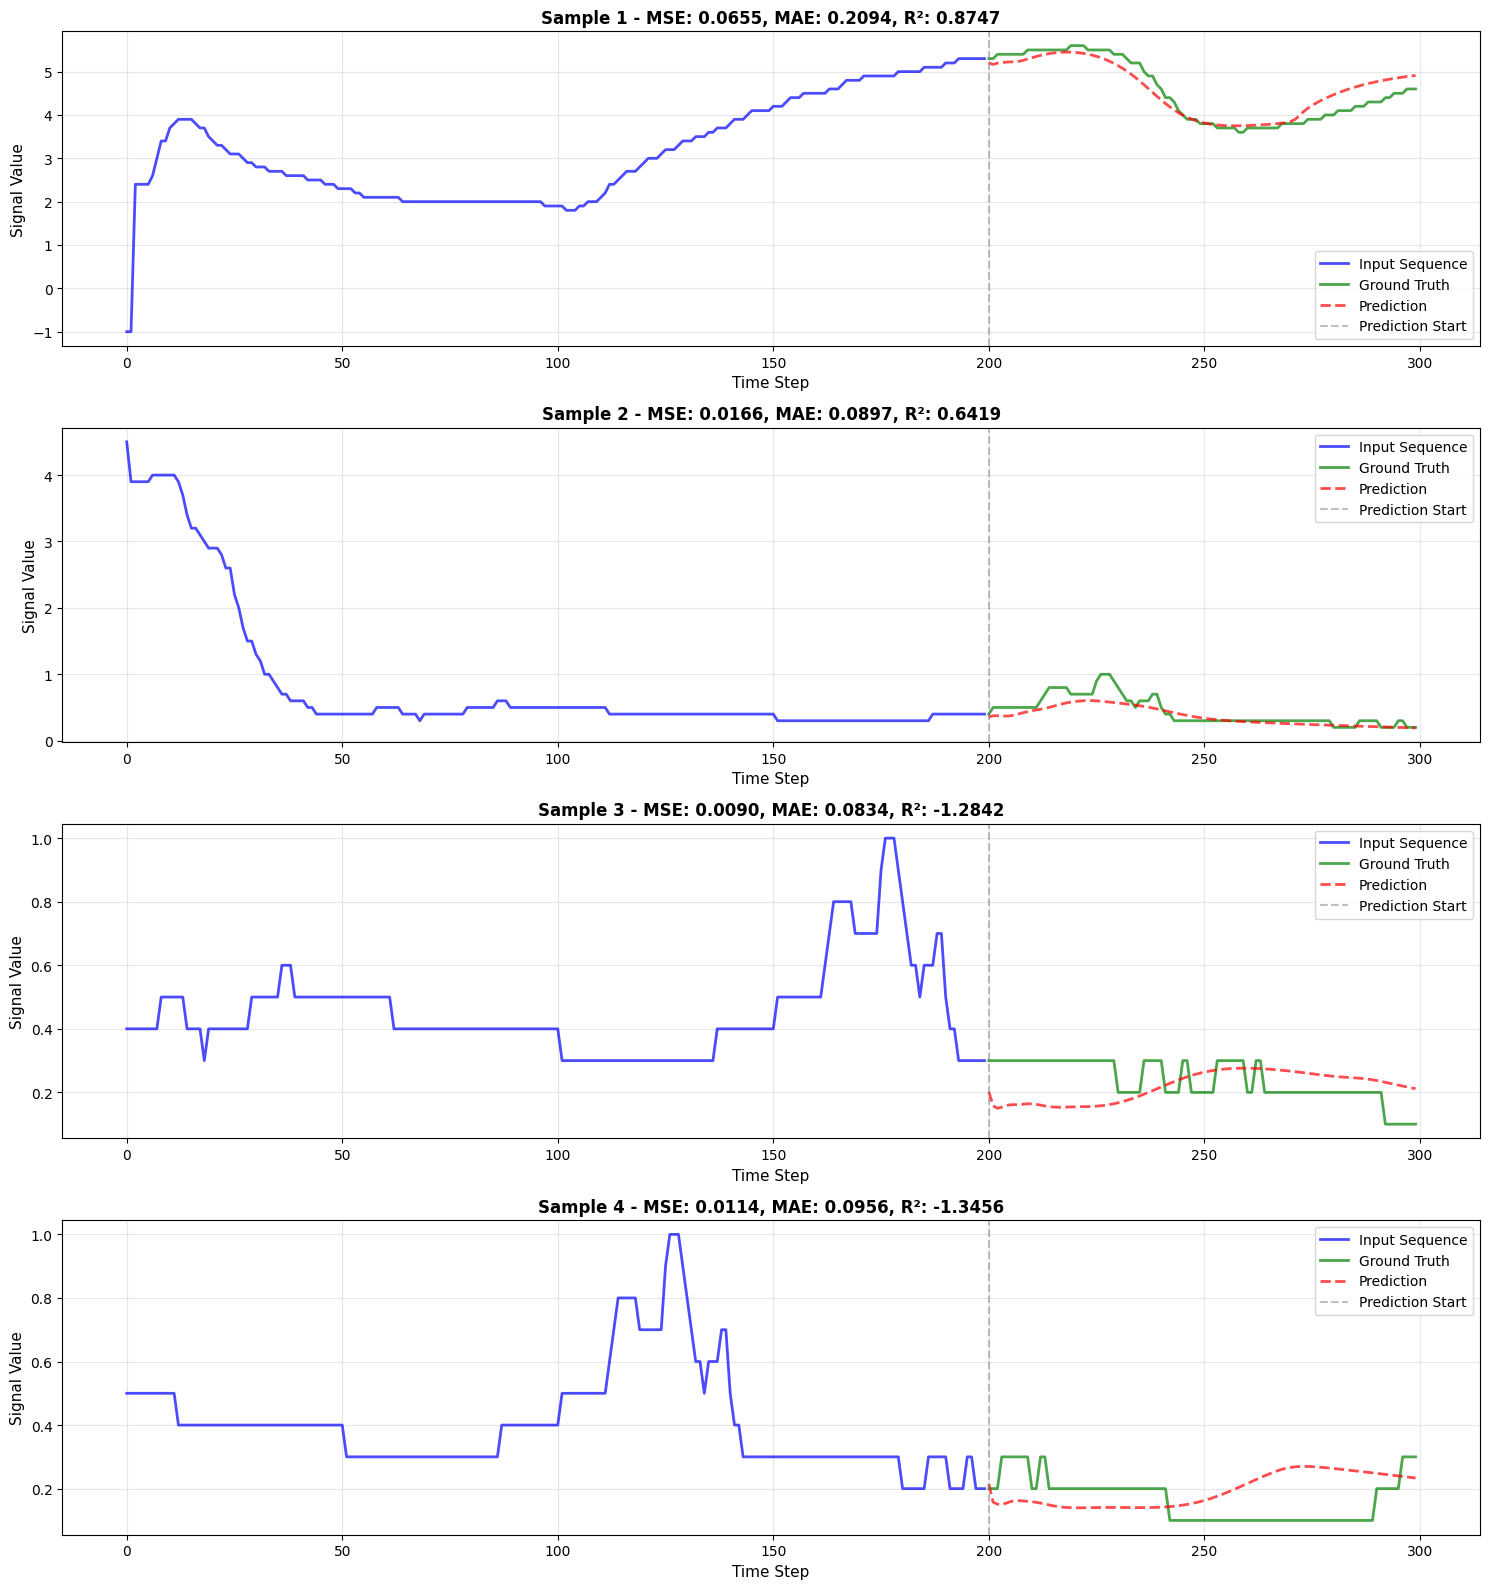

Error distribution plot saved to ./results_optimized/error_distribution.png


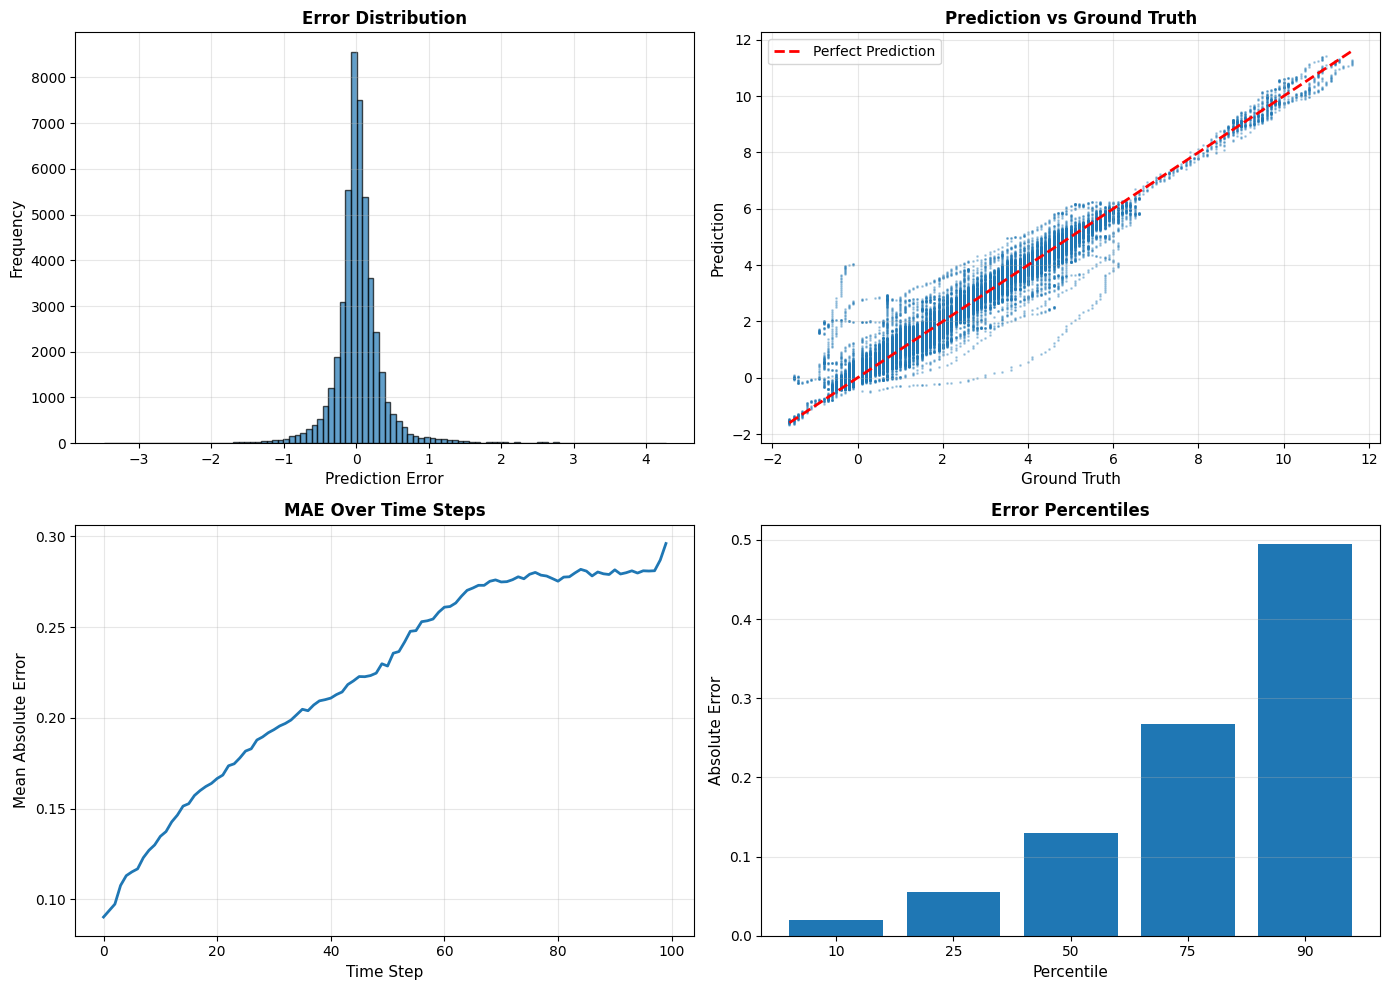


Metrics saved to ./results_optimized/metrics.csv


In [23]:
print("\n加载最佳模型...")

# 加载最佳模型
trainer.load_checkpoint('best_model.pth')

print("\n" + "=" * 60)
print("评估模型...")
print("=" * 60)

# 完整评估
metrics, predictions, targets, inputs = evaluate_model(
    model=trainer.model,
    data_loader=test_loader,
    device=DEVICE,
    save_dir=RESULTS_DIR
)

## 9. 结果分析

In [24]:
# 打印详细指标
print("\n" + "=" * 60)
print("📊 最终评估指标")
print("=" * 60)

for key, value in metrics.items():
    if key == 'R2':
        print(f"{key:10s}: {value:.6f}  ({'✅ 优秀' if value > 0.96 else '⚠️ 需要改进' if value > 0.90 else '❌ 较差'})")
    elif key == 'MAPE':
        print(f"{key:10s}: {value:.2f}%    ({'✅ 优秀' if value < 30 else '⚠️ 需要改进' if value < 50 else '❌ 较差'})")
    else:
        print(f"{key:10s}: {value:.6f}")

print("=" * 60)

# 与基线对比（假设之前的结果）
print("\n📈 与基线模型对比:")
baseline_r2 = 0.949
baseline_mape = 63.5

r2_improvement = (metrics['R2'] - baseline_r2) / baseline_r2 * 100
mape_improvement = (baseline_mape - metrics['MAPE']) / baseline_mape * 100

print(f"R² 提升:   {r2_improvement:+.2f}% ({baseline_r2:.4f} → {metrics['R2']:.4f})")
print(f"MAPE 降低: {mape_improvement:+.2f}% ({baseline_mape:.2f}% → {metrics['MAPE']:.2f}%)")


📊 最终评估指标
MSE       : 0.145102
RMSE      : 0.380923
MAE       : 0.221751
R2        : 0.965295  (✅ 优秀)
MAPE      : 38.27%    (⚠️ 需要改进)

📈 与基线模型对比:
R² 提升:   +1.72% (0.9490 → 0.9653)
MAPE 降低: +39.74% (63.50% → 38.27%)


## 10. 单样本预测演示

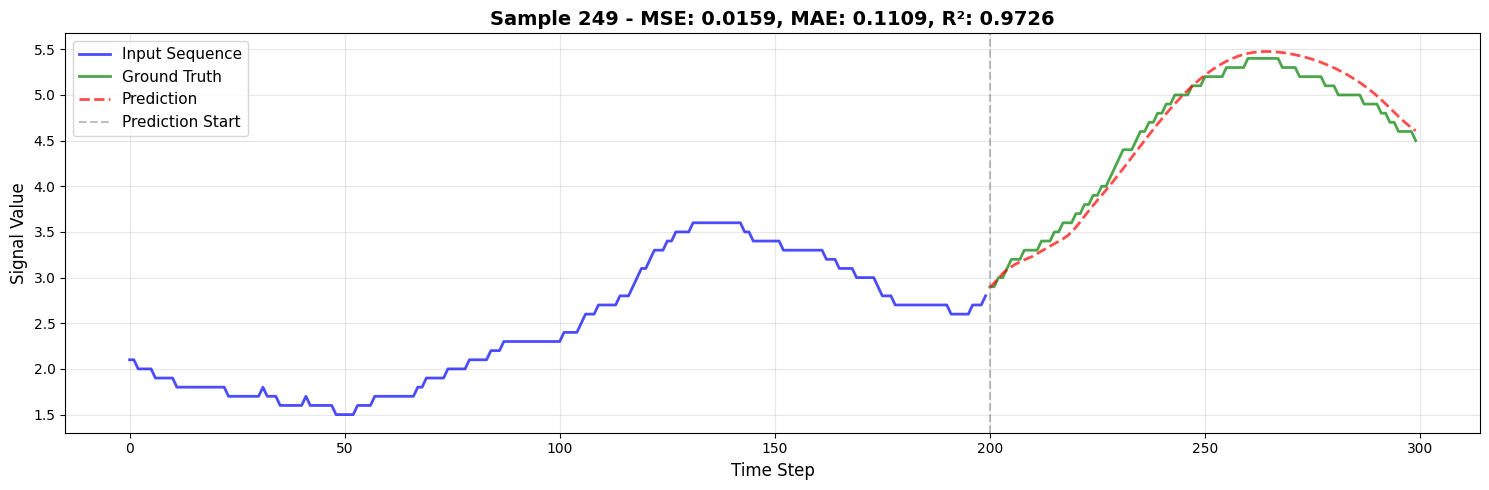


✅ 单样本预测演示图已保存到: ./results_optimized/single_prediction_demo.png


In [25]:
# 随机选择一个测试样本
sample_idx = np.random.randint(0, len(predictions))

# 绘制单个预测
fig, ax = plt.subplots(1, 1, figsize=(15, 5))

input_len = inputs.shape[1]
output_len = predictions.shape[1]

# 时间轴
input_time = np.arange(0, input_len)
output_time = np.arange(input_len, input_len + output_len)

# 绘制输入序列
input_signal = inputs[sample_idx, :, -2] if inputs.shape[2] >= 4 else inputs[sample_idx, :, 0]
ax.plot(input_time, input_signal, 'b-', label='Input Sequence', linewidth=2, alpha=0.7)

# 绘制真实值和预测值
ax.plot(output_time, targets[sample_idx], 'g-', label='Ground Truth', linewidth=2, alpha=0.7)
ax.plot(output_time, predictions[sample_idx], 'r--', label='Prediction', linewidth=2, alpha=0.7)

# 添加分界线
ax.axvline(x=input_len, color='gray', linestyle='--', alpha=0.5, label='Prediction Start')

# 计算误差
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(targets[sample_idx], predictions[sample_idx])
mae = mean_absolute_error(targets[sample_idx], predictions[sample_idx])
r2 = r2_score(targets[sample_idx], predictions[sample_idx])

ax.set_xlabel('Time Step', fontsize=12)
ax.set_ylabel('Signal Value', fontsize=12)
ax.set_title(f'Sample {sample_idx + 1} - MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'single_prediction_demo.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ 单样本预测演示图已保存到: {os.path.join(RESULTS_DIR, 'single_prediction_demo.png')}")

## 11. 保存结果总结

In [26]:
# 创建结果总结
summary = {
    'model_type': MODEL_TYPE,
    'input_dim': INPUT_DIM,
    'hidden_dim': HIDDEN_DIM,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'epochs_trained': len(history['train_loss']),
    'total_params': total_params,
    'device': DEVICE,
}

# ✅ 转换 metrics 中的 numpy 类型为 Python 原生类型（修复 JSON 序列化问题）
for key, value in metrics.items():
    summary[key] = float(value)

# 保存为 JSON
import json
with open(os.path.join(RESULTS_DIR, 'training_summary.json'), 'w') as f:
    json.dump(summary, f, indent=4)

print("\n" + "=" * 60)
print("✅ 训练完成！结果已保存")
print("=" * 60)
print(f"模型保存在:   {MODEL_SAVE_DIR}")
print(f"结果保存在:   {RESULTS_DIR}")
print(f"\n生成的文件:")
print(f"  - {MODEL_SAVE_DIR}/best_model.pth")
print(f"  - {MODEL_SAVE_DIR}/final_model.pth")
print(f"  - {MODEL_SAVE_DIR}/training_history.json")
print(f"  - {RESULTS_DIR}/training_history.png")
print(f"  - {RESULTS_DIR}/predictions.png")
print(f"  - {RESULTS_DIR}/error_distribution.png")
print(f"  - {RESULTS_DIR}/metrics.csv")
print(f"  - {RESULTS_DIR}/training_summary.json")
print("=" * 60)


✅ 训练完成！结果已保存
模型保存在:   ./models_optimized
结果保存在:   ./results_optimized

生成的文件:
  - ./models_optimized/best_model.pth
  - ./models_optimized/final_model.pth
  - ./models_optimized/training_history.json
  - ./results_optimized/training_history.png
  - ./results_optimized/predictions.png
  - ./results_optimized/error_distribution.png
  - ./results_optimized/metrics.csv
  - ./results_optimized/training_summary.json


## 12. 进一步优化建议

如果 LSTM 效果还不够理想，可以尝试：

### 方案 1: 增加模型容量
```python
# 回到第 3 节，修改配置
HIDDEN_DIM = 512       # 从 256 增加到 512
NUM_LAYERS = 4         # 从 3 增加到 4
```

### 方案 2: 调整序列长度
```python
# 如果预测 400 步太难，可以减少
OUTPUT_LENGTH = 200    # 从 400 减少到 200

# 或者增加输入长度
INPUT_LENGTH = 150     # 从 100 增加到 150
```

### 方案 3: 尝试不同的模型
```python
MODEL_TYPE = 'gru'     # GRU 通常更快且不易过拟合
```

### 方案 4: 微调训练参数
```python
LEARNING_RATE = 0.0005      # 降低学习率
EPOCHS = 150                # 更多训练轮次
BATCH_SIZE = 64             # 增加批次大小
```

### 方案 5: 集成多个模型
训练 3-5 个不同配置的 LSTM 模型，然后平均它们的预测结果。
详见 `OPTIMIZATION_GUIDE.md` 中的集成学习方案。

---

## 🔍 诊断工具

### 检查训练是否收敛
```python
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss')
plt.legend()
plt.show()
```

### 检查学习率调度
```python
plt.plot(history['learning_rate'])
plt.title('Learning Rate Schedule')
plt.show()
```

### 分析预测误差模式
```python
errors = predictions - targets
plt.hist(errors.flatten(), bins=100)
plt.title('Prediction Error Distribution')
plt.show()
```

---

## 📚 相关文档
- [README.md](README.md) - 项目概述
- [DATA_FORMAT.md](DATA_FORMAT.md) - 数据格式说明
- [OPTIMIZATION_GUIDE.md](OPTIMIZATION_GUIDE.md) - 详细优化指南

---

## 💡 LSTM 工作原理

**编码器阶段**：
- 读取 100 步输入序列
- 提取时间序列特征
- 生成隐藏状态（记忆）

**解码器阶段**（自回归）：
- 从编码器隐藏状态开始
- 逐步生成 400 步预测
- 每一步的输出作为下一步的输入

这种架构特别适合长序列预测任务！